# Maximum Independent Set using QAOA

## Problem statement
Given an undirected graph $G = (V, E)$ with $n$ vertices in $V$ and $m$ edges in $E$, what is the maximum number of nodes should be choosen such that the choosen nodes are not neighbor to each other?

## Demonstrating the graph

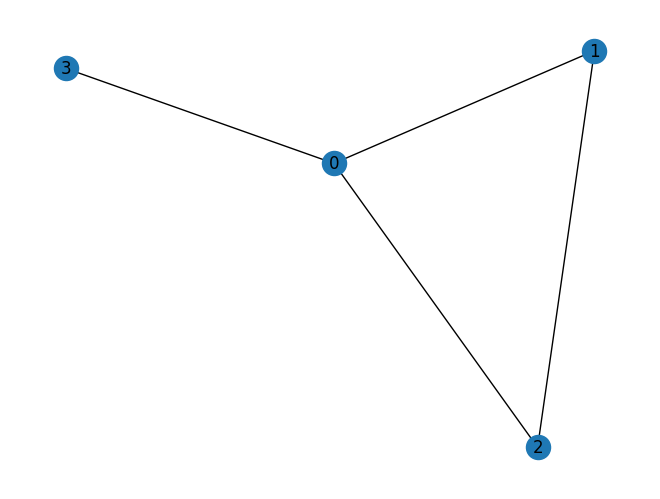

In [1]:
import numpy as np
import rustworkx as rx
from rustworkx.visualization import mpl_draw

default_color = "#1f78b4"
mark_color = "red"

# n, m = map(int, input().split())
# edges = [(x1 - 1, x2 - 1) for x1, x2 in (map(int, input().split()) for _ in range(m))]

n = 4
edges = [
    (0, 1), (1, 2), (2, 0), (3, 0)
]   

G = rx.PyGraph()
G.add_nodes_from(range(n))
for x1, x2 in edges:
    G.add_edge(x1, x2, None)

mpl_draw(G, with_labels=True, label=list(range(n)))


## Representing the problem with QUBO model
Define set $M$ is the maximum independent set of $G = (V, E)$. We also define $x_i$ where vertex $i \in V$ as:

$$
\displaystyle 
\begin{cases}
x_i = 1, i \in M \\
x_i = 0, i \notin M
\end{cases}
$$

In other words, if we choose vertex $i$ to be in set M, then we have count it 1. This means for MIS problem, we want to maximize:

$$\displaystyle \sum_{i \in V}^{}x_i $$

Which is equivalent to minimizing (we will be using this formula instead):

$$\displaystyle -\sum_{i \in V}^{}x_i $$

This function $f(x)$, however, need to be constrained to:

$$x_i + x_j \leq 1$$

The constraint above means for every edge $(i, j) \in E$, we want to make sure $i$ and $j$ are not picked in $M$ simultaneously. To enforce this constraint to our minimized formula, we want to have a penalty portion to increase the minimized formula to detect if we satisfy the constraint after finding MIS:

$$\displaystyle P\sum_{(i, j) \in E}^{}x_i x_j$$

Our final QUBO model for MIS problem would then be:

$$\displaystyle f_{QUBO}(x) = -\sum_{i \in V}^{}x_i + P\sum_{(i, j) \in E}^{}x_i x_j$$

$P$ is the amplitude of penalty we want to choose for a specific problem. Usually, it would be the expected optimal solution to the problem. The reason we want to adjust it is because in QAOA, the more we scale this constant $P$, the more exhausted the machine might suffers. In this MIS problem, the optimal choice we can pick for $P$ is the number of vertices $V$ we have in $G$. 

For that reason, if $P = n$, and somehow in our solution we have an invalid pair of vertices $i$ and $j$, we increase $f_{QUBO}$ such that $f_{QUBO} \ge 0$. Vice versa, if there is no invalid pair of vertices $i$ and $j$, we have $f_{QUBO} \lt 0$. Hence, we can detect whether our solution has penalty or not.

We can express the Maximum Independent Set (MIS) problem in QUBO form as

$$
f_{\text{QUBO}}(x) = x^T Q x
$$

where the binary decision vector is

$$
x =
\begin{bmatrix}
x_0 \\
x_1 \\
\vdots \\
x_{n-1}
\end{bmatrix},
\quad
x_i \in \{0,1\}.
$$

The QUBO matrix $Q \in \mathbb{R}^{n \times n}$ is defined as

$$
Q =
\begin{bmatrix}
-1 & \frac{P}{2} e_{(0,1)} & \frac{P}{2} e_{(0,2)} & \cdots & \frac{P}{2} e_{(0,n-1)} \\
\frac{P}{2} e_{(1,0)} & -1 & \frac{P}{2} e_{(1,2)} & \cdots & \frac{P}{2} e_{(1,n-1)} \\
\vdots & \vdots & \ddots & \vdots & \vdots \\
\frac{P}{2} e_{(n-1,0)} & \frac{P}{2} e_{(n-1,1)} & \cdots & \cdots & -1
\end{bmatrix},
$$

where $P > 0$ is the penalty parameter and

$$
e_{(i,j)} =
\begin{cases}
1 & \text{if } (i,j) \in E, \\
0 & \text{otherwise}.
\end{cases}
$$

Equivalently, if $A$ denotes the adjacency matrix of the graph $G = (V,E)$, then

$$
A_{ij} =
\begin{cases}
1 & \text{if } (i,j) \in E, \\
0 & \text{otherwise},
\end{cases}
$$

the QUBO matrix can be written compactly as

$$
Q = -I + \frac{P}{2} A,
$$

where $I$ is the identity matrix.



## Brute-forcing with QUBO formula

Maximum independent set value: [[2]]
Configuration: [0 1 0 1]
EdgeList[(0, 1), (1, 2), (2, 0), (3, 0)]


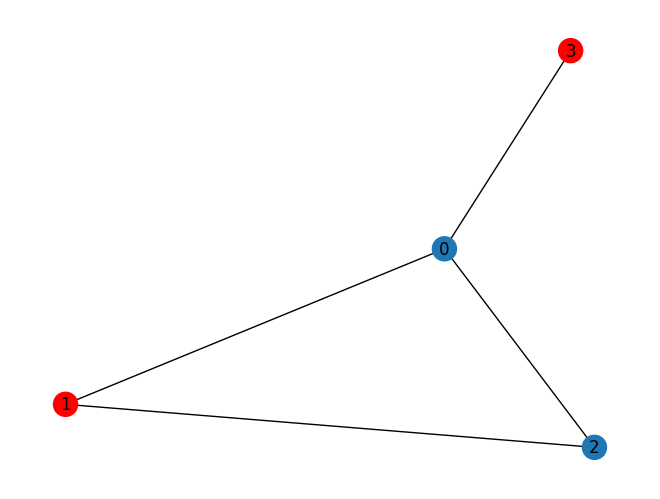

In [2]:
def qubo_maximum_independent_set(n: int, edges: list[tuple[int, int]]) -> (int, list[int]):
    penalty = n

    Q = np.matrix([[0] * n] * n)

    for i in range(n):
        Q[i, i] = -1

    for i, j in edges:
        Q[i, j] = Q[j, i] = penalty / 2

    min_val = 0
    configuration = None
    for i in range(2**n):
        x = np.array([(i >> j) & 1 for j in range(n)])
        indep_set_value = x.T @ Q @ x
        if indep_set_value < min_val:
            min_val = indep_set_value
            configuration = x

    return -min_val, configuration

max_indep_set_value, configuration = qubo_maximum_independent_set(n, edges)
print("Maximum independent set value:", max_indep_set_value)
print("Configuration:", configuration)

print(G.edge_list())

G2 = rx.PyGraph()
G2 = G.copy()
color = [mark_color if configuration[i] == 1 else default_color for i in range(n)]
mpl_draw(G2, with_labels=True, label=list(range(n)), node_color = color)

## Solution Graph (Energy Graph)

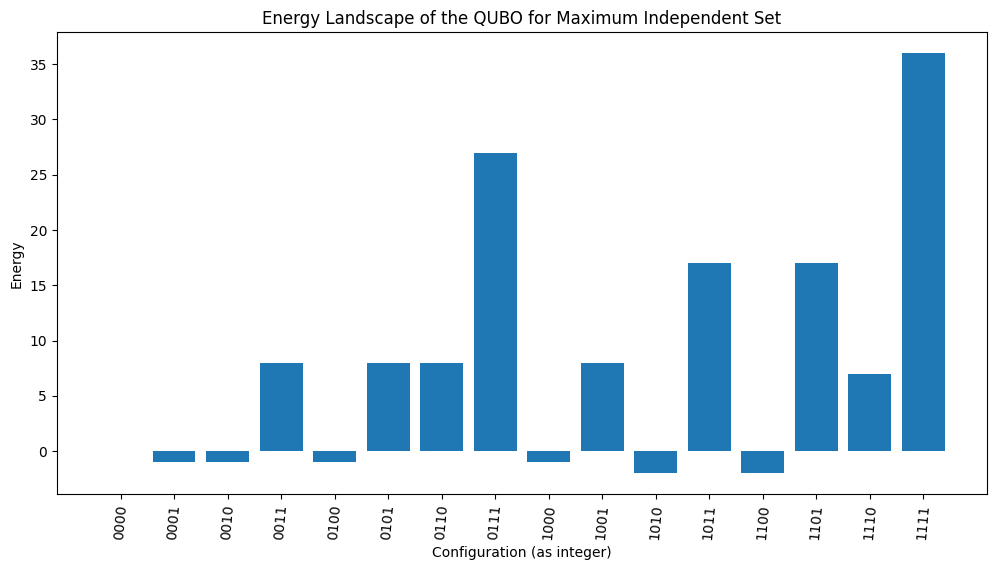

In [3]:
import matplotlib.pyplot as plt
def energy(n: int, edges: list[tuple[int, int]], configuration: list[int]) -> int:
    penalty = n + 1

    Q = np.matrix([[0] * n] * n)

    for i in range(n):
        Q[i, i] = -1

    for i, j in edges:
        Q[i, j] = Q[j, i] = penalty

    return (configuration.T @ Q @ configuration).item()
    

map = {f"{i:0{n}b}": 0 for i in range(2 ** n)}
for i in range(2 ** n):
    x = np.array([(i >> j) & 1 for j in range(n)])
    map[f"{i:0{n}b}"] = energy(n, edges, x)

x = list(map.keys())
y = list(map.values())
plt.figure(figsize=(12, 6))
plt.xticks(rotation=85)
plt.bar(x, y)
plt.xlabel('Configuration (as integer)')
plt.ylabel('Energy')
plt.title('Energy Landscape of the QUBO for Maximum Independent Set')
plt.show()

## Expected Energy Graph

Text(0.5, 1.0, 'Expected Energy Landscape of the QUBO for Maximum Independent Set')

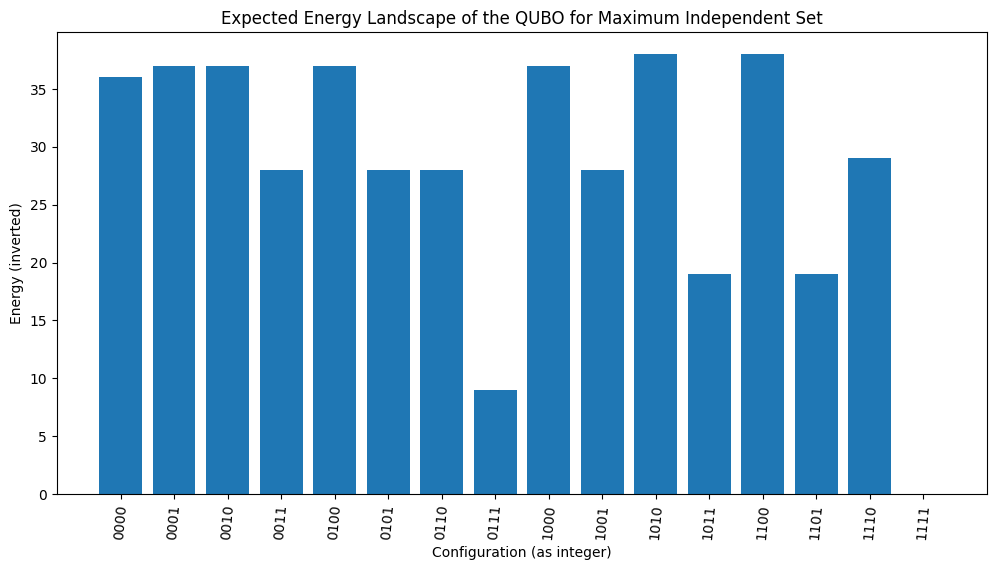

In [4]:
highest_energy = max(map.values())
for key in map.keys():
    map[key] = -map[key] + highest_energy

x = list(map.keys())
y = list(map.values())
plt.figure(figsize=(12, 6))
plt.xticks(rotation=85)
plt.bar(x, y)
plt.xlabel('Configuration (as integer)')
plt.ylabel('Energy (inverted)')
plt.title('Expected Energy Landscape of the QUBO for Maximum Independent Set')

## Turn it into an Ising Hamiltonian

Hamiltonian system only works for $z_i \in {\{-1, 1\}}^n$ instead of $x_i \in {\{0, 1\}}^n$. Therefore, we need to convert $x_i$ into $z_i$ via:

$$z_i = \frac{1 - x_i}{2}$$

By substituting $z_i$ into $f_{QUBO}(x)$, we have: 

$$ \displaystyle f_{QUBO}(z) = \frac{1}{4}\sum_{ij}^{}Q_{ij}(1 - z_i)(1 - z_j) $$

After doing some linear algebra, we got:

$$ \displaystyle f_{QUBO}(z) = \frac{1}{4}\sum_{ij}^{}Q_{ij}z_iz_j - \frac{1}{4}\sum_{ij}^{}(Q_{ij} + Q_{ji})z_i + \frac{n^2}{4}$$

By dropping $\frac{1}{4}$ and $\frac{n^2}{4}$ (which is not important in optimization) and setting $b = \sum_{ij}^{}(Q_{ij} + Q_{ji})z_i$, we have:

$$ \displaystyle f_{QUBO}(z) =  z^TQz - b^Tz$$

## Build The Pauli Opertors

In [5]:
from qiskit.quantum_info import SparsePauliOp

def eval_cost_hamiltonian(G: rx.PyGraph, configuration: list[int]):
    n = G.num_nodes()
    P = 1  # assuming P = number of nodes
    q = [-1] * n
    
    # Convert -1/1 configuration to x_i in {0,1}
    # -1 -> yes -> x_i = 1, 1 -> no -> x_i = 0
    z = configuration  # z_i = 1 if node i is in the independent set, else 0
    
    cost = 0
    # Quadratic edge term
    for i, j in G.edge_list():
        cost -= (P / 4) * z[i]
        cost -= (P / 4) * z[j]
        cost += P / 4
        cost += (P / 4) * z[i] * z[j]
    
    # Linear term
    for i in range(n):
        cost += 0.5 * q[i]
        cost -= 0.5 * q[i] * z[i]

    
    return cost

# Example usage
# config = [-1, 1, -1, 1, -1]
# cost = eval_cost_hamiltonian(G, config)
# print(f"Cost of configuration {config}:", cost)

def build_mis_paulis(G: rx.PyGraph):

    n = G.num_nodes()
    P = n  # assuming P = number of nodes
    q = [-1] * n
    pauli_list = []

    # ZZ terms (edge penalties)
    for i, j in G.edge_list():
        pauli_list.append(("ZZ", [i, j], P / 4))
        pauli_list.append(("Z", [i], -P / 4))
        pauli_list.append(("Z", [j], -P / 4))

    # Z terms (vertex rewards + edge corrections)
    for v in G.node_indices():
        pauli_list.append(("Z", [v], -0.5 * q[v]))

    return pauli_list

mis_paulis = build_mis_paulis(G)
mis_hamiltonian = SparsePauliOp.from_sparse_list(mis_paulis, n)

print("MIS Hamiltonian:", mis_hamiltonian)


MIS Hamiltonian: SparsePauliOp(['IIZZ', 'IIIZ', 'IIZI', 'IZZI', 'IIZI', 'IZII', 'IZIZ', 'IZII', 'IIIZ', 'ZIIZ', 'ZIII', 'IIIZ', 'IIIZ', 'IIZI', 'IZII', 'ZIII'],
              coeffs=[ 1. +0.j, -1. +0.j, -1. +0.j,  1. +0.j, -1. +0.j, -1. +0.j,  1. +0.j,
 -1. +0.j, -1. +0.j,  1. +0.j, -1. +0.j, -1. +0.j,  0.5+0.j,  0.5+0.j,
  0.5+0.j,  0.5+0.j])


## Build Circuit Layout with one layer of Ansatz

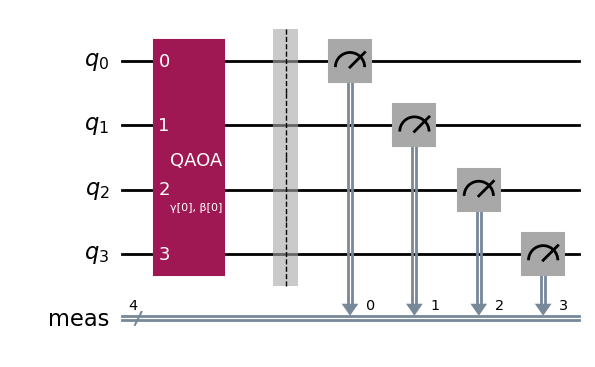

In [6]:
from qiskit.circuit.library import QAOAAnsatz

circuit_wo_measure = QAOAAnsatz(cost_operator=mis_hamiltonian, reps=1)
circuit = circuit_wo_measure.copy()
circuit.measure_all()

circuit.draw("mpl")

## Guess initial Gamma and Beta

     ┌──────────────────┐
q_0: ┤0                 ├
     │                  │
q_1: ┤1                 ├
     │  QAOA(γ[0],β[0]) │
q_2: ┤2                 ├
     │                  │
q_3: ┤3                 ├
     └──────────────────┘


/home/tuthuanvanvn/miniconda3/envs/molssi_best_practices/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/tuthuanvanvn/miniconda3/envs/molssi_best_practices/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/tuthuanvanvn/miniconda3/envs/molssi_best_practices/lib/python3.11/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Expectation value: (4.163336342344337e-17+0j)
{np.str_('0000'): np.int64(81), np.str_('0001'): np.int64(76), np.str_('0010'): np.int64(67), np.str_('0011'): np.int64(57), np.str_('0100'): np.int64(62), np.str_('0101'): np.int64(64), np.str_('0110'): np.int64(59), np.str_('0111'): np.int64(52), np.str_('1000'): np.int64(47), np.str_('1001'): np.int64(60), np.str_('1010'): np.int64(50), np.str_('1011'): np.int64(66), np.str_('1100'): np.int64(78), np.str_('1101'): np.int64(68), np.str_('1110'): np.int64(88), np.str_('1111'): np.int64(49)}


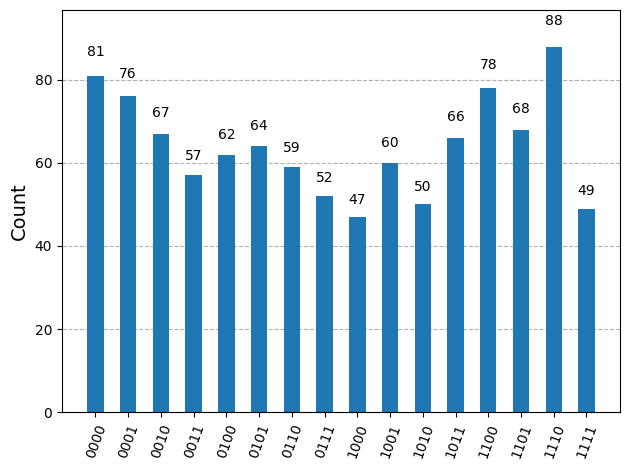

In [7]:

init_gamma = np.pi
init_beta = np.pi / 2
param_dict = {p: init_beta if 'β' in str(p) else init_gamma for p in circuit_wo_measure.parameters}

circuit_bound = circuit_wo_measure.assign_parameters(param_dict)
print(circuit_wo_measure)

from qiskit import quantum_info as qi

psi = qi.Statevector(circuit_bound)

counts = psi.sample_counts(1024)
expectation_value = psi.expectation_value(mis_hamiltonian)
print("Expectation value:", expectation_value)
print(counts)

from qiskit.visualization import plot_histogram
plot_histogram(counts)


## Find the good Gamma and Beta

/home/tuthuanvanvn/miniconda3/envs/molssi_best_practices/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/tuthuanvanvn/miniconda3/envs/molssi_best_practices/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/tuthuanvanvn/miniconda3/envs/molssi_best_practices/lib/python3.11/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -1.0008864777547055
       x: [ 2.833e+00  2.026e+00]
    nfev: 35
   maxcv: 0.0


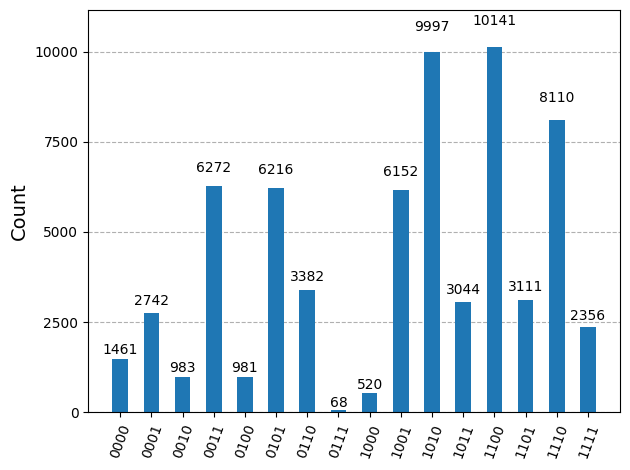

In [8]:
from scipy.optimize import minimize

def objective(params):
    param_dict = {circuit_wo_measure.parameters[i].name: params[i] for i in range(len(circuit_wo_measure.parameters))}
    circuit_bound = circuit_wo_measure.assign_parameters(param_dict)
    psi = qi.Statevector(circuit_bound)
    return np.real(psi.expectation_value(mis_hamiltonian))

result = minimize(objective, x0=[init_beta, init_gamma], method='COBYLA')

print(result)

circuit_bound = circuit_wo_measure.assign_parameters({circuit_wo_measure.parameters[i].name: result.x[i] for i in range(len(circuit_wo_measure.parameters))})
psi = qi.Statevector(circuit_bound)
counts = psi.sample_counts(2 ** 16)
plot_histogram(counts)

# Try 3 layers and find good Gamma and Betas

In [19]:
r = 4
circuit_wo_measure = QAOAAnsatz(cost_operator=mis_hamiltonian, reps=r)
params = [np.pi / 2] * r + [np.pi] * r
print(len(circuit_wo_measure.parameters))
result = minimize(objective, x0=params, method='COBYLA')

8


 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -3.0075037543830607
       x: [ 3.311e+00  9.003e-01  1.653e+00  2.159e+00  4.320e+00
            4.351e+00]
    nfev: 774
   maxcv: 0.0


/home/tuthuanvanvn/miniconda3/envs/molssi_best_practices/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/tuthuanvanvn/miniconda3/envs/molssi_best_practices/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/tuthuanvanvn/miniconda3/envs/molssi_best_practices/lib/python3.11/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


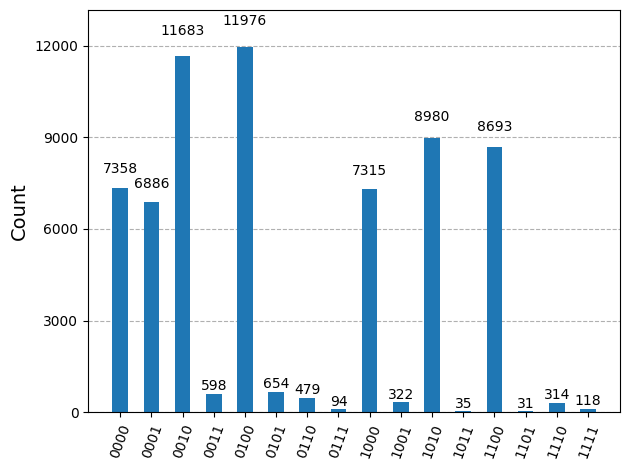

In [17]:
print(result)
circuit_bound = circuit_wo_measure.assign_parameters({circuit_wo_measure.parameters[i].name: result.x[i] for i in range(len(circuit_wo_measure.parameters))})
psi = qi.Statevector(circuit_bound)
counts = psi.sample_counts(1024 * 64)
plot_histogram(counts)

## Poll only highest 25 states

In [11]:
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
print(sorted_counts)
subset = {k: v for i, (k, v) in enumerate(sorted_counts) if i < 25}
plot_histogram(subset)

## Check whether the top 25 configurations are independent sets
def is_independent_set(G: rx.PyGraph, config: str) -> bool:
    nodes_in_set = [i for i, bit in enumerate(config) if bit == '1']
    for i in range(len(nodes_in_set)):
        for j in range(i + 1, len(nodes_in_set)):
            if G.has_edge(nodes_in_set[i], nodes_in_set[j]):
                return False
    return True

for config, count in subset.items():
    print(f"Config: {config}, Count: {count}, Is independent set: {is_independent_set(G, config)}")

[(np.str_('0001'), np.int64(20608)), (np.str_('0010'), np.int64(10990)), (np.str_('0100'), np.int64(10687)), (np.str_('0000'), np.int64(9913)), (np.str_('1100'), np.int64(2911)), (np.str_('1010'), np.int64(2857)), (np.str_('1000'), np.int64(2669)), (np.str_('1001'), np.int64(1859)), (np.str_('0101'), np.int64(750)), (np.str_('0011'), np.int64(720)), (np.str_('0111'), np.int64(518)), (np.str_('0110'), np.int64(452)), (np.str_('1111'), np.int64(409)), (np.str_('1011'), np.int64(99)), (np.str_('1101'), np.int64(91)), (np.str_('1110'), np.int64(3))]
Config: 0001, Count: 20608, Is independent set: True
Config: 0010, Count: 10990, Is independent set: True
Config: 0100, Count: 10687, Is independent set: True
Config: 0000, Count: 9913, Is independent set: True
Config: 1100, Count: 2911, Is independent set: False
Config: 1010, Count: 2857, Is independent set: False
Config: 1000, Count: 2669, Is independent set: True
Config: 1001, Count: 1859, Is independent set: False
Config: 0101, Count: 750, 

### NOTE

1. Understand why P is too large can lead to optimization landscape going bad
2. QAOA Ansatz?
3. Find a paper that talk about the more energy scale, the more layers of QAOA Ansatz needed -> Lead to more computation for optimizing gamma, beta

I. Definition, Background in MIS problem and Motivation

II. Proposed solution, QAOA with minimization of gamma and beta
    1. QUBO Formula forming, Hamiltonian
    2. QAOA Circuit built
    3. Minimize gamma and beta using COBYLA

III. Experiments

IV. Time complexity analyze of the algorithm & compare to classical method

V. Future steps and further other version of the problem
    1. May use different COBYLA method (most factor)
    2. May choose different penalty (second factor)
    3. Optimize the circuit and QUBO form (least factor)

    1. MIS with different weight for each node
    2. K-distance independent set 

Testing MIS:
n = 8
edges = [
    (0, 1),
    (0, 2),
    (1, 3),
    (2, 3),
    (3, 4),
    (4, 5),
    (4, 6),
    (5, 7),
    (6, 7),
    (2, 5)
]

Find $\gamma$ and $\beta$ takes about 90 minutes
1000 COBYLA iterations (max)
Run the circuit give a high probs on correct solution takes about 5 seconds with 2^16 shots
With 4.100e+00  2.898e+00  2.948e+00  3.276e+00  3.321e+00 Beta
            1.640e+00  1.426e+00  1.454e+00  1.398e+00  1.512e+00 Gamma